#Wine Quality Prediction

##Importing Dependencies

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Splitting
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Classification Algorithms
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

#Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

#Evaluation Metrics (Classification)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

#Evaluation Metrics (Clustering)
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)

print('All libraries imported successfully!')

All libraries imported successfully!


##Data Collection & Exploration

In [24]:
# Load dataset
wine_dataset = pd.read_csv('winequality-red.csv')

print('Shape:', wine_dataset.shape)
wine_dataset.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [25]:
print('Dataset Info:')
wine_dataset.info()
print('\nMissing Values:')
print(wine_dataset.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar   

In [26]:
wine_dataset.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


##Data Analysis & Visualization

C:\Users\yugka\AppData\Local\Temp\ipykernel_26020\3745537710.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=wine_dataset, palette='viridis', ax=axes[0])
C:\Users\yugka\AppData\Local\Temp\ipykernel_26020\3745537710.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='quality', y='volatile acidity', data=wine_dataset, palette='coolwarm', ax=axes[1])


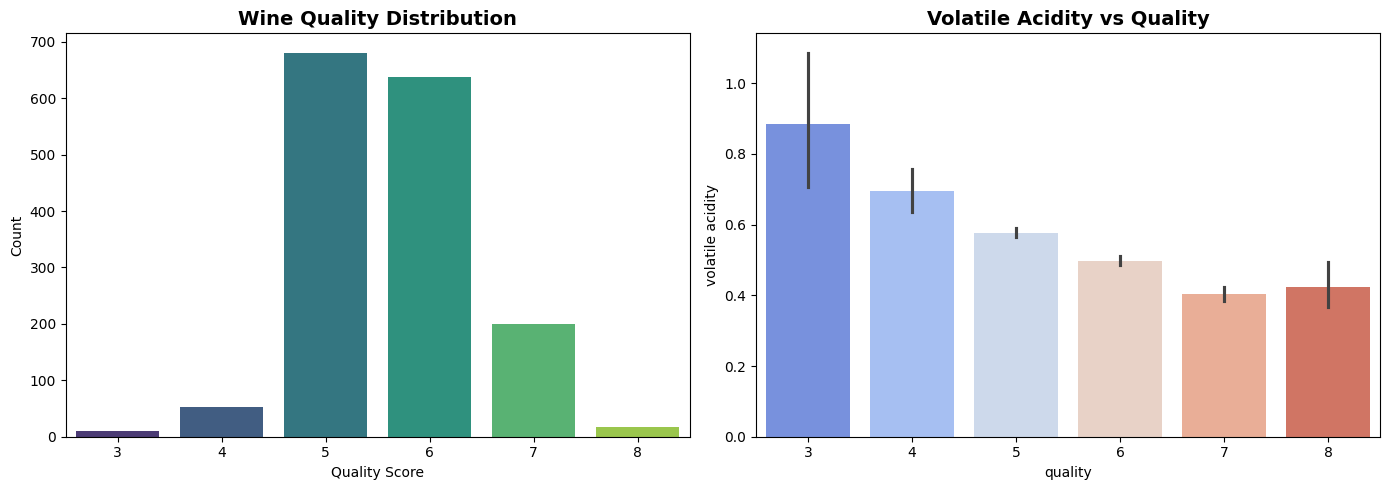

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quality distribution
sns.countplot(x='quality', data=wine_dataset, palette='viridis', ax=axes[0])
axes[0].set_title('Wine Quality Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')

# Volatile acidity vs Quality
sns.barplot(x='quality', y='volatile acidity', data=wine_dataset, palette='coolwarm', ax=axes[1])
axes[1].set_title('Volatile Acidity vs Quality', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

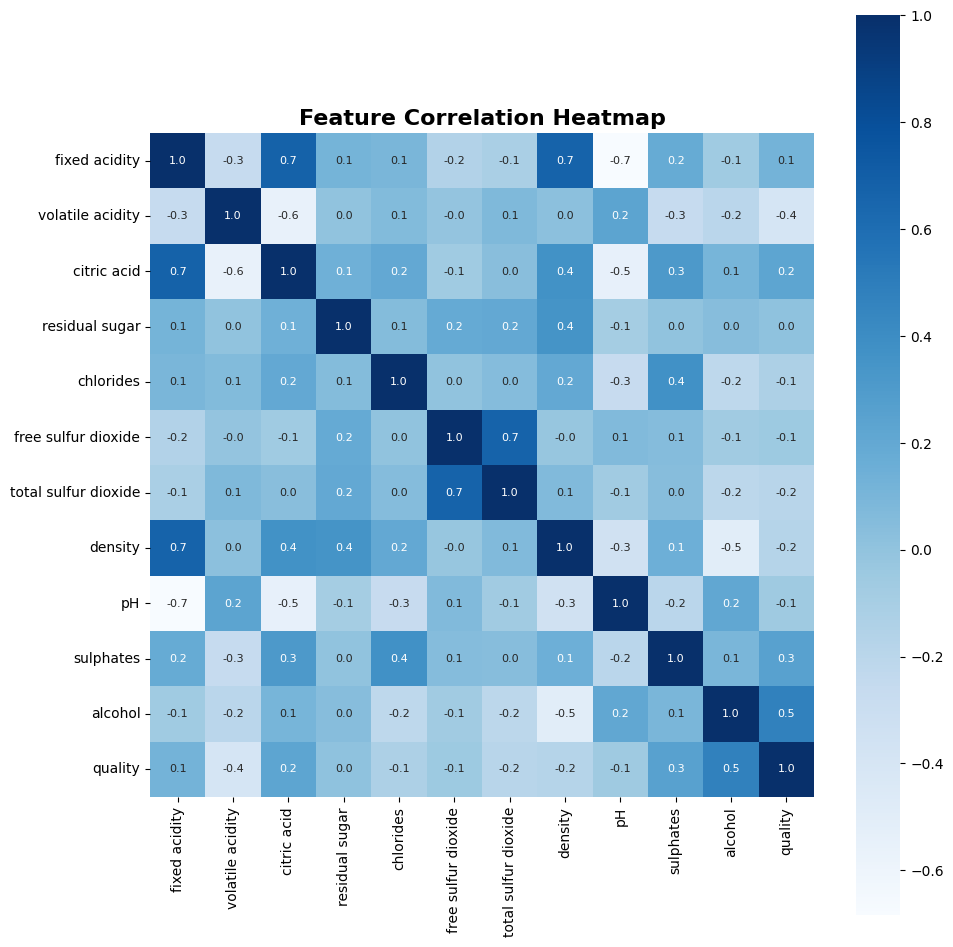

In [28]:
# Correlation Heatmap
plt.figure(figsize=(10, 10))
correlation = wine_dataset.corr()
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',
            annot=True, annot_kws={'size': 8}, cmap='Blues')
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##Data Preprocessing

In [29]:
# Features and Label
X = wine_dataset.drop('quality', axis=1)
Y = wine_dataset['quality'].apply(lambda y: 1 if y >= 7 else 0)

print('Class Distribution:')
print(Y.value_counts())

# Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42, stratify=Y
)

print(f'\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Class Distribution:
quality
0    1382
1     217
Name: count, dtype: int64

Train size: 1279 | Test size: 320


## Classification Algorithms
### Algorithms Applied:
1. Random Forest Classifier
2. Support Vector Machine (SVM)
3. K-Nearest Neighbors (KNN)
4. Logistic Regression
5. Gradient Boosting Classifier

In [30]:
# classifiers
classifiers = {
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                  SVC(kernel='rbf', probability=True, random_state=42),
    'KNN':                  KNeighborsClassifier(n_neighbors=7),
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Storage for results
clf_results = {}
trained_models = {}

# Train & Evaluate Each Classifier
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in classifiers.items():
    # Train
    clf.fit(X_train, Y_train)
    trained_models[name] = clf

    # Predict
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    # Cross-validation accuracy
    cv_scores = cross_val_score(clf, X_scaled, Y, cv=cv, scoring='accuracy')

    clf_results[name] = {
        'Accuracy':       accuracy_score(Y_test, y_pred),
        'Precision':      precision_score(Y_test, y_pred),
        'Recall':         recall_score(Y_test, y_pred),
        'F1-Score':       f1_score(Y_test, y_pred),
        'ROC-AUC':        roc_auc_score(Y_test, y_proba),
        'y_pred':         y_pred,
        'y_proba':        y_proba
    }

    print(f'{name} trained successfully')

print('\n All classifiers trained!')

Random Forest trained successfully


c:\Users\yugka\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\yugka\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\yugka\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\yugka\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\

SVM trained successfully
KNN trained successfully
Logistic Regression trained successfully
Gradient Boosting trained successfully

 All classifiers trained!


## **Classification Evaluation**

In [31]:
#Summary

metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_df = pd.DataFrame(
    {name: {m: round(clf_results[name][m], 4) for m in metrics_cols}
     for name in clf_results}
).T


print('          CLASSIFICATION EVALUATION SUMMARY')
print('\n',results_df.to_string())
print('\nBest Model by Accuracy:', results_df['Accuracy'].idxmax())
print('Best Model by F1-Score:', results_df['F1-Score'].idxmax())
print('Best Model by ROC-AUC: ', results_df['ROC-AUC'].idxmax())

          CLASSIFICATION EVALUATION SUMMARY

                      Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest          0.9406     0.9286  0.6047    0.7324   0.9554
SVM                    0.9000     0.7619  0.3721    0.5000   0.8887
KNN                    0.8938     0.6667  0.4186    0.5143   0.8216
Logistic Regression    0.8938     0.6957  0.3721    0.4848   0.8805
Gradient Boosting      0.9156     0.7857  0.5116    0.6197   0.8930

Best Model by Accuracy: Random Forest
Best Model by F1-Score: Random Forest
Best Model by ROC-AUC:  Random Forest


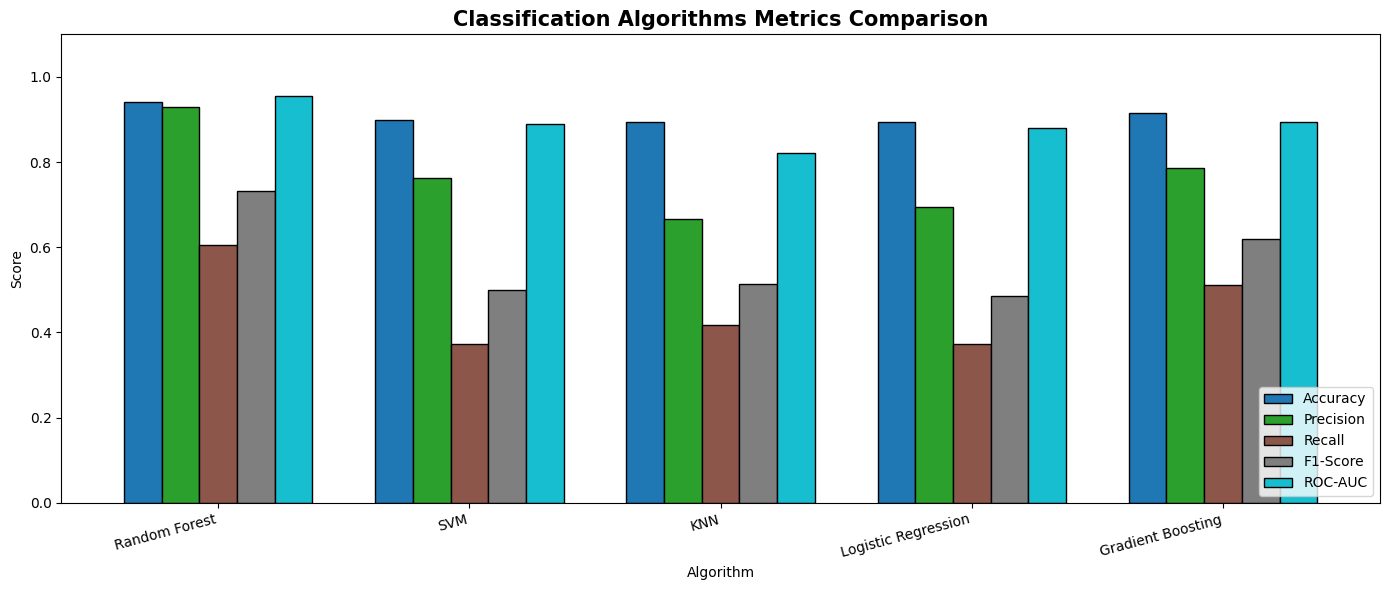

In [32]:
#Bar Chart: Metrics Comparison
plot_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df   = results_df[plot_cols].astype(float)

ax = plot_df.plot(kind='bar', figsize=(14, 6), colormap='tab10', edgecolor='black', width=0.75)
plt.title('Classification Algorithms Metrics Comparison', fontsize=15, fontweight='bold')
plt.xlabel('Algorithm')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

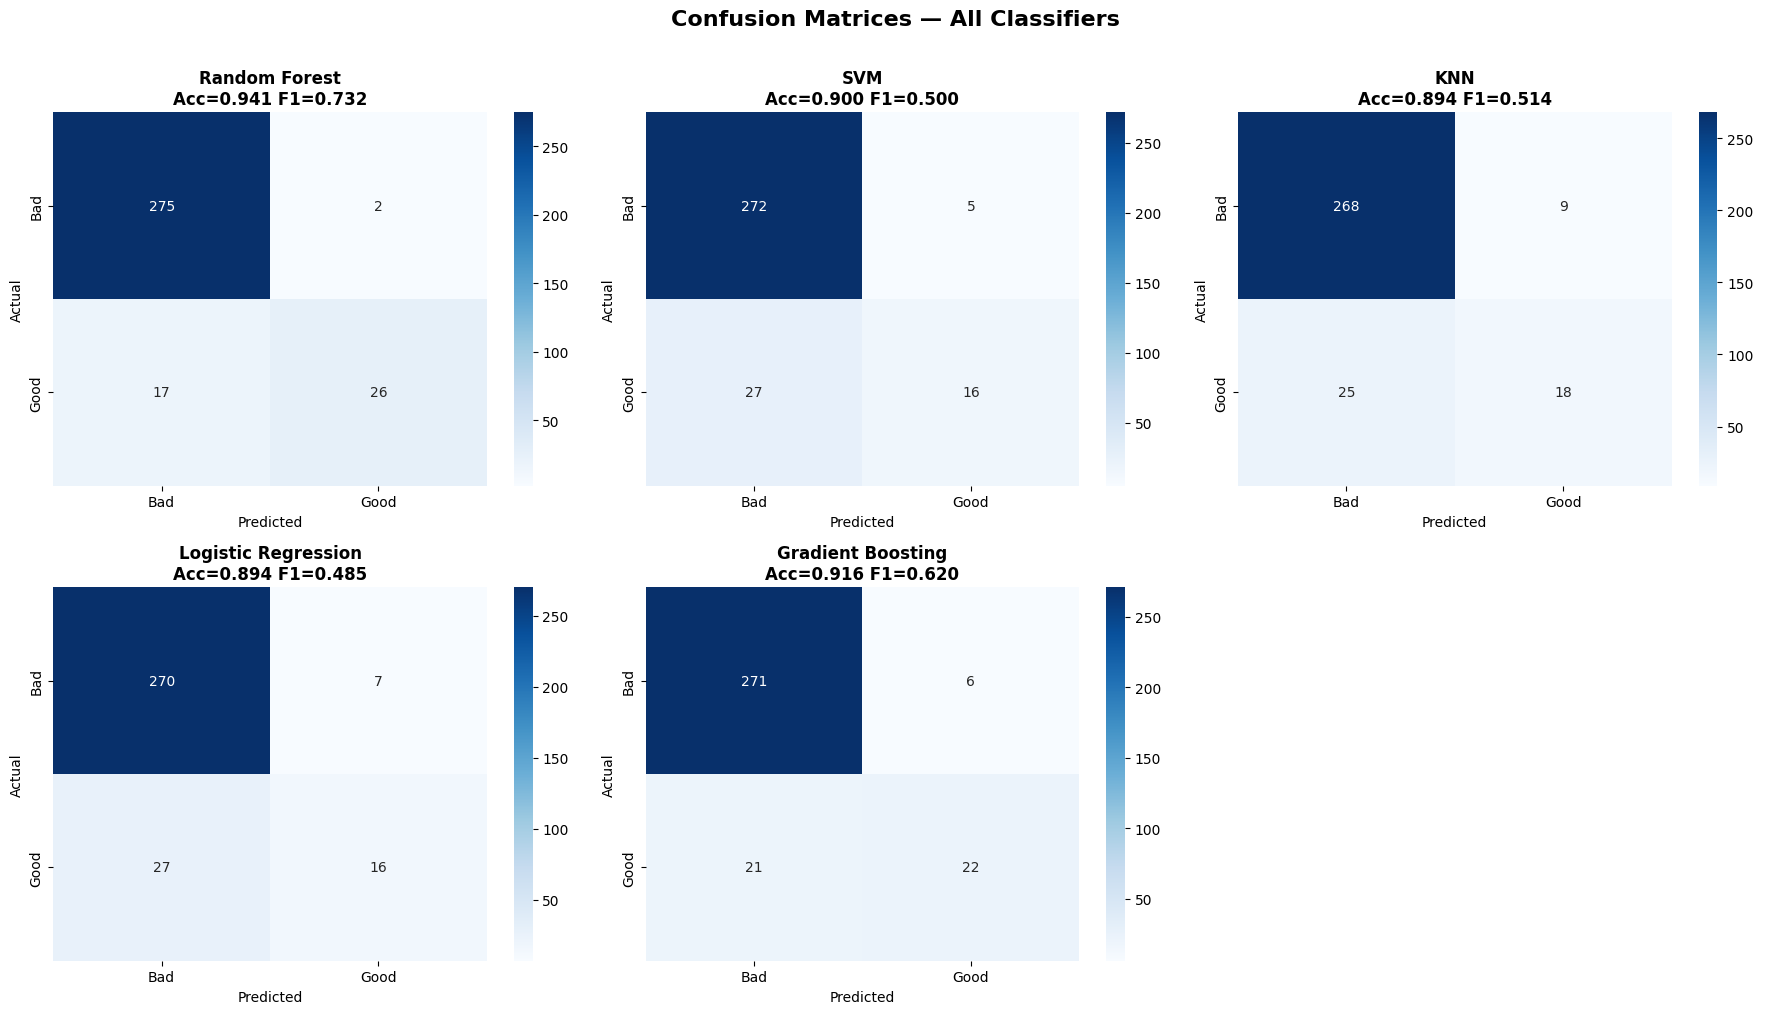

In [33]:
#Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(clf_results.items()):
    cm = confusion_matrix(Y_test, res['y_pred'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])

    axes[idx].set_title(f'{name}\nAcc={res["Accuracy"]:.3f} F1={res["F1-Score"]:.3f}',
                        fontsize=12, fontweight='bold')

    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

axes[-1].axis('off')  # Hide empty subplot
plt.suptitle('Confusion Matrices — All Classifiers', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## **Clustering Algorithms**
### Algorithms Applied:
1. K-Means Clustering
2. Agglomerative (Hierarchical) Clustering
3. DBSCAN (Density-Based Spatial Clustering)

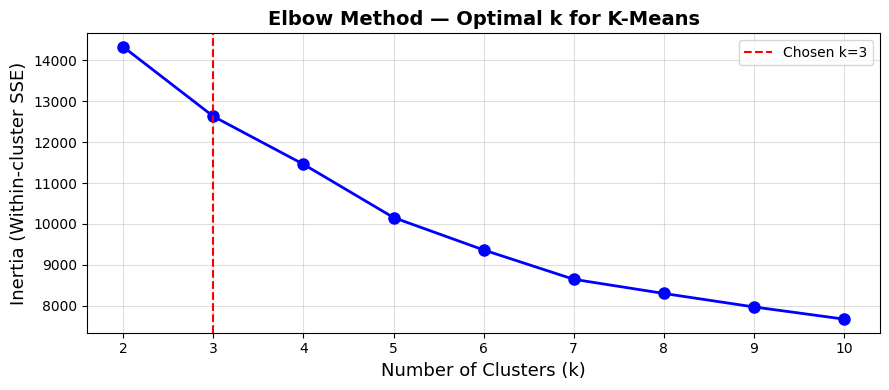

In [34]:
# Elbow Method to find optimal k for K-Means
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(k_range, inertias, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (k)', fontsize=13)
plt.ylabel('Inertia (Within-cluster SSE)', fontsize=13)
plt.title('Elbow Method — Optimal k for K-Means', fontsize=14, fontweight='bold')
plt.axvline(x=3, color='red', linestyle='--', label='Chosen k=3')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [35]:
#Apply Clustering Algorithms

N_CLUSTERS = 3

clustering_models = {
    'K-Means':       KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward'),
    'DBSCAN':        DBSCAN(eps=1.2, min_samples=10)
}

cluster_labels = {}

for name, model in clustering_models.items():
    labels = model.fit_predict(X_scaled)
    cluster_labels[name] = labels
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f'{name}: {n_clusters} clusters found')

print('\n All clustering algorithms applied!')

K-Means: 3 clusters found
Agglomerative: 3 clusters found
DBSCAN: 3 clusters found

 All clustering algorithms applied!


## **Clustering Evaluation**

---



In [36]:
#Clustering Evaluation Metrics
cluster_metrics = {}

for name, labels in cluster_labels.items():
    mask = labels != -1
    X_valid = X_scaled[mask]
    l_valid = labels[mask]
    n_unique = len(set(l_valid))

    if n_unique >= 2:
        sil = silhouette_score(X_valid, l_valid)
        dbi = davies_bouldin_score(X_valid, l_valid)
        chi = calinski_harabasz_score(X_valid, l_valid)
    else:
        sil = dbi = chi = float('nan')

    cluster_metrics[name] = {
        'Silhouette Score':          round(sil, 4),   # Higher is better (max 1)
        'Davies-Bouldin Index':      round(dbi, 4),   # Lower is better (min 0)
        'Calinski-Harabasz Score':   round(chi, 2),   # Higher is better
        'Num Clusters Found':        len(set(l_valid)),
        'Noise Points (DBSCAN)':     list(labels).count(-1)
    }

cluster_eval_df = pd.DataFrame(cluster_metrics).T

print('CLUSTERING EVALUATION SUMMARY')
print(cluster_eval_df.to_string())

CLUSTERING EVALUATION SUMMARY
               Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Score  Num Clusters Found  Noise Points (DBSCAN)
K-Means                  0.1892                1.7673                   313.33                 3.0                    0.0
Agglomerative            0.1577                1.9731                   265.07                 3.0                    0.0
DBSCAN                  -0.0035                1.0782                    22.09                 3.0                 1027.0


C:\Users\yugka\AppData\Local\Temp\ipykernel_26020\3515357695.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(pal, len(unique_labels))


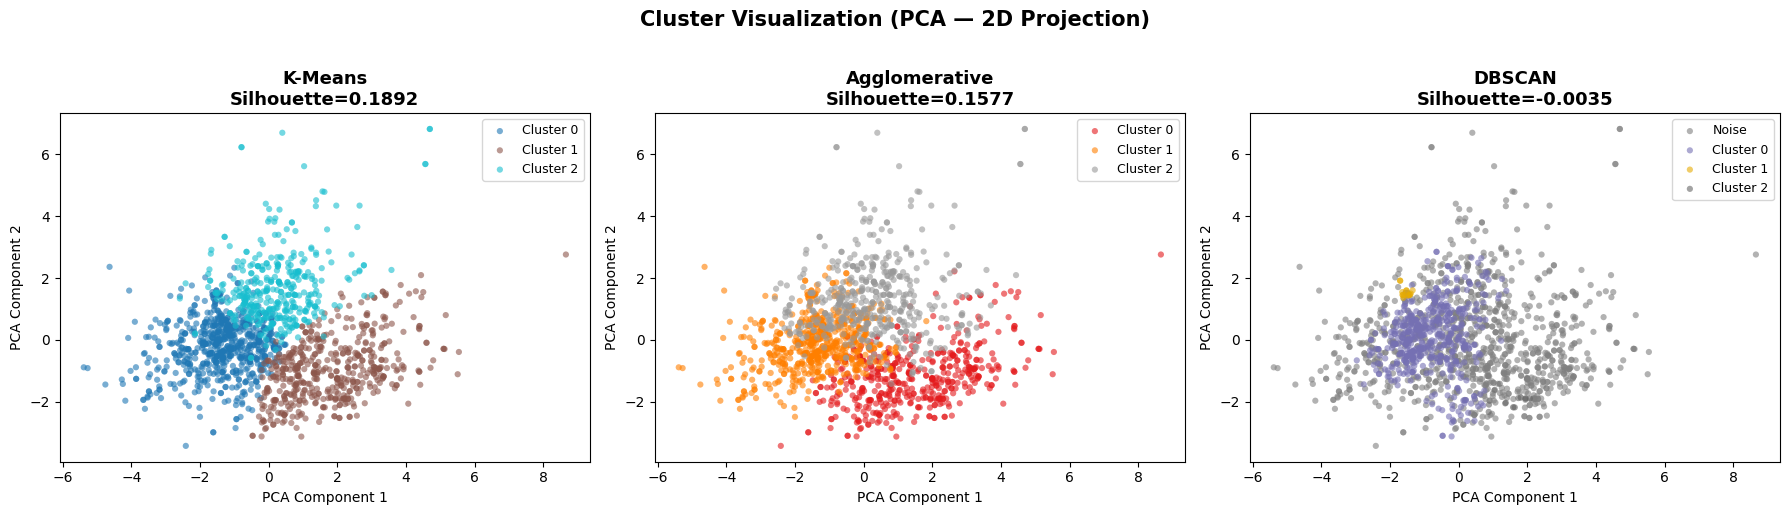

In [37]:
#PCA for 2D Cluster Visualization
from sklearn.decomposition import PCA

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palettes  = ['tab10', 'Set1', 'Dark2']

for ax, (name, labels), pal in zip(axes, cluster_labels.items(), palettes):
    unique_labels = sorted(set(labels))
    colors = plt.cm.get_cmap(pal, len(unique_labels))

    for i, lbl in enumerate(unique_labels):
        mask  = labels == lbl
        label = f'Noise' if lbl == -1 else f'Cluster {lbl}'
        color = 'gray' if lbl == -1 else colors(i)
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[color], label=label, alpha=0.6, s=20, edgecolors='none')

    ax.set_title(f'{name}\nSilhouette={cluster_metrics[name]["Silhouette Score"]}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.legend(loc='best', fontsize=9)

plt.suptitle('Cluster Visualization (PCA — 2D Projection)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

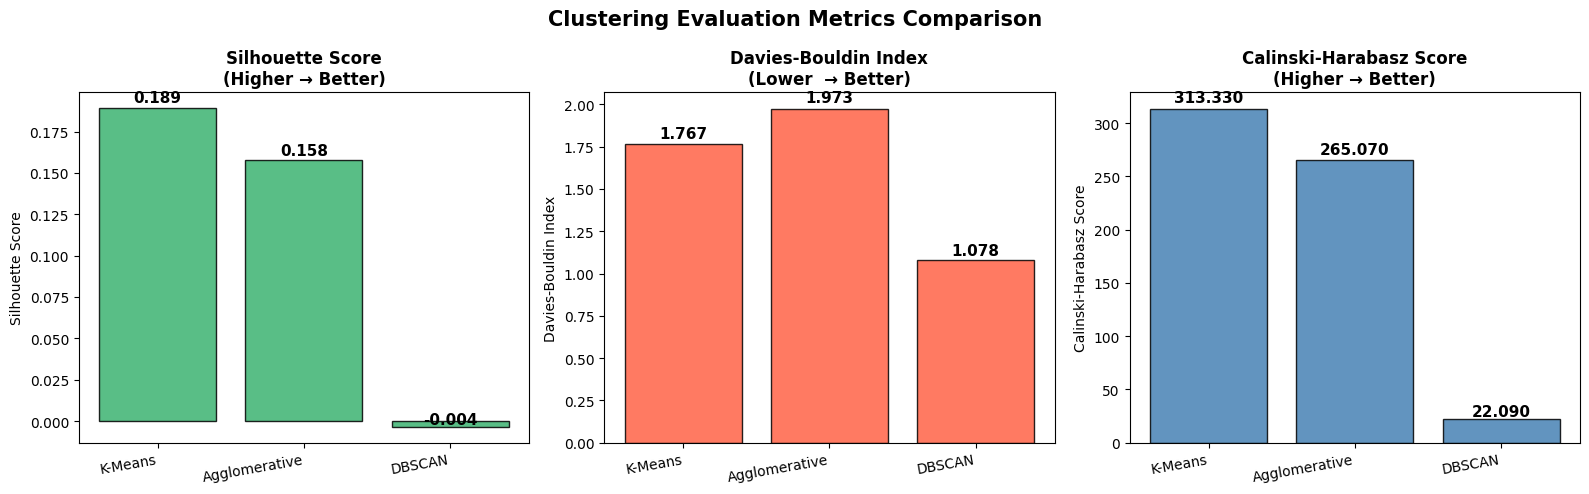

In [38]:
#Clustering Metrics Bar Charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metric_info = [
    ('Silhouette Score',        'Higher → Better', 'mediumseagreen'),
    ('Davies-Bouldin Index',    'Lower  → Better', 'tomato'),
    ('Calinski-Harabasz Score', 'Higher → Better', 'steelblue')
]

for ax, (metric, note, color) in zip(axes, metric_info):
    vals  = cluster_eval_df[metric].astype(float)
    names = vals.index
    bars  = ax.bar(names, vals, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'{metric}\n({note})', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=10, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Clustering Evaluation Metrics Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Prediction Using Best Classifier

In [40]:
best_accuracy = results_df['Accuracy'].astype(float).idxmax()
best_f1 = results_df['F1-Score'].astype(float).idxmax()
best_roc_auc = results_df['ROC-AUC'].astype(float).idxmax()

In [41]:
# Use best model by F1-score for prediction
best_model = trained_models[best_f1]

# input: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free SO2, total SO2, density, pH, sulphates, alcohol
input_data = (7.5, 0.5, 0.36, 6.1, 0.071, 17.0, 102.0, 0.9978, 3.35, 0.8, 10.5)

# Scale input
input_array   = np.asarray(input_data).reshape(1, -1)
input_scaled  = scaler.transform(input_array)

prediction    = best_model.predict(input_scaled)
probability   = best_model.predict_proba(input_scaled)[0]

print(f'Model Used      : {best_f1}')
print(f'Prediction      : {prediction[0]} ({"Good Quality" if prediction[0]==1 else "Bad Quality"})')
print(f'Prob(Bad=0)     : {probability[0]:.4f}')
print(f'Prob(Good=1)    : {probability[1]:.4f}')

if prediction[0] == 1:
    print('\nThis is a GOOD Quality Wine!')
else:
    print('\n This is a BAD Quality Wine.')

Model Used      : Random Forest
Prediction      : 0 (Bad Quality)
Prob(Bad=0)     : 1.0000
Prob(Good=1)    : 0.0000

 This is a BAD Quality Wine.


c:\Users\yugka\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\yugka\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\yugka\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
